# AutoGluon SHAP Derivation

NOT WORKING

In [ ]:
# =============================================================================
# Cell 1: Notebook Preamble and Imports
# =============================================================================
# ---
# # Notebook: SHAP Analysis of the Top AutoGluon Model
#
# **Objective:**
# This notebook implements the "pragmatic approach" for explaining our AutoGluon model.
# The steps are:
# 1. Train an AutoGluon TabularPredictor on the combined pre-op and intra-op dataset.
# 2. Identify the single best-performing **Level 1** model from the ensemble.
# 3. Verify that the best L1 model is a tree-based model (like LightGBM or XGBoost).
# 4. Extract and save this L1 model for direct use with the fast `shap.TreeExplainer`.
# 5. Prepare the test data by applying AutoGluon's internal transformations.
# 6. Calculate SHAP values for the entire test set using the fast TreeExplainer.
# ---

import os
import time
import pandas as pd
import numpy as np
import pickle
import shutil # Imported for robustly deleting directories

# Make sure to install autogluon and shap if you haven't already
# !pip install -U pip
# !pip install -U "autogluon[all]" shap
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
import shap

# Set SHAP to use a javascript-based plotting method for notebooks
shap.initjs()

print("Libraries imported successfully.")


# =============================================================================
# Cell 2: Configuration and Paths
# =============================================================================
# --- Configuration ---
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# --- File Paths ---
# PLEASE UPDATE these paths to match your system
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = '/home/server/Projects/data/AKI/results/autogluon_analysis/'
NORMALIZATION_STATS_PATH = '/home/server/Projects/data/base/normalization_stats.csv'

# Create the results directory if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)

# Path to the source data
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')

# Paths to save our trained models to avoid re-training
# Path for the full AutoGluon predictor
PREDICTOR_PATH = os.path.join(RESULTS_DIR, 'autogluon_predictor_combined')
# Path for the single best model extracted from the predictor
BEST_MODEL_PATH = os.path.join(RESULTS_DIR, 'best_single_model.pkl')


print(f"Results will be saved in: {RESULTS_DIR}")


# =============================================================================
# Cell 3: Load and Split Data
# =============================================================================
print(f"Loading data from {DATA_PATH}...")
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    print("Please update the BASE_DATA_DIR variable in Cell 2.")
    # In a real notebook, you might stop execution here
    df = pd.DataFrame() # Create empty df to avoid further errors

if not df.empty:
    # Drop identifier columns that are not features
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    print("Performing an 80/20 stratified train/test split...")
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )

    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")


# =============================================================================
# Cell 4: Train or Load the Full AutoGluon Predictor
# =============================================================================
if not df.empty:
    # More robust check: The main directory AND the essential predictor.pkl must exist.
    predictor_pkl_path = os.path.join(PREDICTOR_PATH, 'predictor.pkl')
    if os.path.exists(predictor_pkl_path):
        try:
            print(f"Found existing predictor. Attempting to load from: {PREDICTOR_PATH}")
            predictor = TabularPredictor.load(PREDICTOR_PATH)
            print("Predictor loaded successfully.")
        except Exception as e:
            # Catch any error during loading (corrupted files, etc.)
            print(f"WARNING: Failed to load predictor due to an error: {e}")
            print("The saved model directory appears to be corrupted.")
            print(f"Deleting corrupted directory: {PREDICTOR_PATH}")
            shutil.rmtree(PREDICTOR_PATH) # Automatically delete the broken folder
            print("Directory deleted. The model will be retrained from scratch.")
            predictor = None # Ensure predictor is None to trigger retraining
    else:
        # This branch is taken if the main directory or the pkl file doesn't exist.
        print(f"No valid, complete predictor found at {PREDICTOR_PATH}. Training a new model.")
        predictor = None # Ensure predictor is None to trigger retraining

    if predictor is None:
        print(f"Starting training at {time.ctime()}...")
        predictor = TabularPredictor(
            label=TARGET,
            path=PREDICTOR_PATH,
            eval_metric='balanced_accuracy',
            sample_weight='balance_weight'
        )

        # --- FIX: Added `save_bag_folds=True` to ensure child models are saved ---
        predictor.fit(
            train_data=train_df,
            # time_limit=300,
            presets='best_quality',
            save_bag_folds=True, # This forces AutoGluon to keep the child models for bagged ensembles.
            num_cpus=8,
            ag_args_fit={'num_gpus': 1}
        )
        print(f"Training complete. Predictor saved to {PREDICTOR_PATH}")

    # Display the final performance summary on the test set
    print("\n--- Predictor Performance Summary ---")
    predictor.leaderboard(test_df)


# =============================================================================
# Cell 5: Identify and Verify the Best Level 1 Model
# =============================================================================
if not df.empty:
    print("\n--- Identifying the Best Level 1 Model for SHAP Analysis ---")
    
    leaderboard = predictor.leaderboard(test_df)
    
    # Filter the leaderboard to only include models from the base level (stack_level=1)
    l1_leaderboard = leaderboard[leaderboard['stack_level'] == 1]
    
    if l1_leaderboard.empty:
        raise ValueError("Could not find any Level 1 models in the leaderboard.")
        
    # Get the name of the top-performing L1 model (already sorted by score)
    best_l1_model_name = l1_leaderboard.iloc[0]['model']
    print(f"The best performing Level 1 model is: '{best_l1_model_name}'")

    # Define the model types that work with the fast shap.TreeExplainer
    acceptable_tree_models = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'ExtraTrees']

    # Check if the best model is one of our acceptable types
    if any(best_l1_model_name.startswith(prefix) for prefix in acceptable_tree_models):
        print(f"Success! The best L1 model is a tree-based model compatible with shap.TreeExplainer.")
    else:
        raise TypeError(
            f"The best L1 model '{best_l1_model_name}' is not an accepted tree-based model. "
            "This analysis plan requires a tree-based model."
        )


# =============================================================================
# Cell 6: Extract and Save the Best Single Model
# =============================================================================
if not df.empty:
    if os.path.exists(BEST_MODEL_PATH):
        print(f"\nLoading best single model from: {BEST_MODEL_PATH}")
        with open(BEST_MODEL_PATH, 'rb') as f:
            best_model = pickle.load(f)
        print("Model loaded successfully.")
    else:
        print(f"\nExtracting '{best_l1_model_name}' from the predictor...")
        # Load the chosen L1 model (which is likely a BaggedEnsemble)
        l1_model_ensemble = predictor._trainer.load_model(best_l1_model_name)

        # Check if the loaded L1 model is a bagged ensemble and unwrap it
        if hasattr(l1_model_ensemble, 'models') and l1_model_ensemble.models:
            print(f"The extracted model is a '{type(l1_model_ensemble).__name__}'. Unwrapping to get the base model object.")
            
            # The .models attribute can contain model objects OR their string names.
            # We must handle both cases.
            potential_model = l1_model_ensemble.models[0]
            
            if isinstance(potential_model, str):
                # If it's a string, it's the name. Load it from the trainer.
                print(f"Loading the underlying base model: '{potential_model}'")
                unwrapped_model = predictor._trainer.load_model(potential_model)
            else:
                # If it's not a string, it's the model object itself.
                unwrapped_model = potential_model

            print(f"Extracted the base model of type: '{type(unwrapped_model).__name__}'")
            print(f"Saving the unwrapped base model to: {BEST_MODEL_PATH}")
            with open(BEST_MODEL_PATH, 'wb') as f:
                pickle.dump(unwrapped_model, f)
            print("Base model saved successfully.")
            
            # Assign the truly unwrapped model to the variable we will use for SHAP
            best_model = unwrapped_model
        else:
            # This case handles non-bagged models, saving them directly.
            print(f"The extracted model is a simple model. Saving it directly to: {BEST_MODEL_PATH}")
            with open(BEST_MODEL_PATH, 'wb') as f:
                pickle.dump(l1_model_ensemble, f)
            print("Model saved successfully.")
            best_model = l1_model_ensemble

    # Display the model object that will be used for SHAP analysis
    print("\n--- Final Model Object for SHAP Analysis ---")
    print(best_model)
    

# =============================================================================
# Cell 7: Preprocess Data for SHAP Analysis
# =============================================================================
# The single best_model was trained on data that AutoGluon preprocessed internally.
# We must apply the exact same transformations to our test data before explaining it.
if not df.empty:
    print("\n--- Preparing Test Data for the Extracted Model ---")
    
    # Separate the features from the target variable *before* transformation
    X_test = test_df.drop(columns=[TARGET])
    y_test = test_df[TARGET]

    # Use the predictor's internal data preprocessing pipeline to transform the test set
    # This ensures the data format matches what the model was trained on.
    X_test_transformed = predictor.transform_features(X_test)
    
    print("Test data transformed successfully.")
    print(f"Shape of transformed test data: {X_test_transformed.shape}")
    

# =============================================================================
# Cell 8: Calculate SHAP Values
# =============================================================================
# Now we can use the fast TreeExplainer on our extracted LightGBM model
# and the transformed test data to calculate SHAP values for the entire test set.
if not df.empty:
    print("\n--- Calculating SHAP values using TreeExplainer ---")
    
    # 1. Create the explainer with the single, extracted tree model
    explainer = shap.TreeExplainer(best_model)
    
    # 2. Calculate the SHAP values. This will be very fast.
    #    The output is a raw numpy array.
    print(f"Starting SHAP calculation for {len(X_test_transformed)} samples at {time.ctime()}...")
    shap_values_raw = explainer.shap_values(X_test_transformed)
    print(f"SHAP calculation finished at {time.ctime()}.")

    # 3. Create a modern SHAP Explanation object. This bundles the values,
    #    base values (expected value), and the data itself into one convenient object.
    #    This is the standard object used by all modern SHAP plotting functions.
    shap_explanation = shap.Explanation(
        values=shap_values_raw,
        base_values=explainer.expected_value,
        data=X_test_transformed,
        feature_names=X_test_transformed.columns.tolist()
    )

    print("\nSHAP Explanation object created successfully.")
    print(f"SHAP values shape: {shap_explanation.values.shape}")
    print(f"Data shape: {shap_explanation.data.shape}")

# XGBoost Derivation

In [ ]:
# =============================================================================
# Cell 1: Notebook Preamble and Imports
# =============================================================================
# ---
# # Notebook: SHAP Analysis for XGBoost Model
#
# **Objective:**
# This notebook trains an XGBoost model using the specific hyperparameters
# from the benchmarking script, saves the model, and then calculates SHAP values
# for the entire test set using the fast `shap.TreeExplainer`.
# ---

import os
import time
import pandas as pd
import numpy as np
import pickle
import shutil

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap

# Set SHAP to use a javascript-based plotting method for notebooks
shap.initjs()

print("Libraries imported successfully.")


# =============================================================================
# Cell 2: Configuration and Paths
# =============================================================================
# --- Configuration ---
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# --- File Paths ---
# PLEASE UPDATE these paths to match your system
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
# Using a separate directory for XGBoost results to keep things organized
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# Create the results directory if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)

# Path to the source data
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
NORMALIZATION_STATS_PATH = '/home/server/Projects/data/base/normalization_stats.csv'

# Paths for saving the trained model and the final SHAP values
MODEL_PATH = os.path.join(RESULTS_DIR, 'xgboost_model.json')
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')
SHAP_VALUES_PROB_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_prob.pkl')


print(f"Results will be saved in: {RESULTS_DIR}")


# =============================================================================
# Cell 3: Load Hyperparameters for the 'combined' Dataset
# =============================================================================
# These are the optimized hyperparameters for XGBoost on the 'combined' dataset
# from your original benchmarking script.
hpo_params_combined = {
    'xgb': {
        'n_estimators': 1110,
        'learning_rate': 0.0172,
        'max_depth': 9,
        'subsample': 0.8281,
        'colsample_bytree': 0.7827,
        'gamma': 1.7456
    }
}
xgb_params = hpo_params_combined['xgb']
print("XGBoost hyperparameters loaded:")
print(xgb_params)


# =============================================================================
# Cell 4: Load and Split Data
# =============================================================================
print(f"\nLoading data from {DATA_PATH}...")
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    print("Please update the BASE_DATA_DIR variable in Cell 2.")
    df = pd.DataFrame()

if not df.empty:
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    print("Performing an 80/20 stratified train/test split...")
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )
    
    # Separate features (X) from the target (y)
    X_train_raw = train_df.drop(columns=[TARGET])
    y_train = train_df[TARGET]
    X_test_raw = test_df.drop(columns=[TARGET])
    y_test = test_df[TARGET]

    print(f"Training data shape: {X_train_raw.shape}")
    print(f"Test data shape: {X_test_raw.shape}")


# =============================================================================
# Cell 5: Preprocess Data (Scaling)
# =============================================================================
# Unlike AutoGluon, tree-based models like XGBoost often benefit from scaled data.
# We will scale the features before training.
if not df.empty:
    print("\n--- Scaling Data ---")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    # For creating the final SHAP explanation, it's useful to have these as DataFrames
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

    print("Training and test data have been scaled.")


# =============================================================================
# Cell 6: Train or Load the XGBoost Model
# =============================================================================
if not df.empty:
    if os.path.exists(MODEL_PATH):
        print(f"\nFound existing model. Loading from: {MODEL_PATH}")
        model = xgb.XGBClassifier()
        model.load_model(MODEL_PATH)
        print("Model loaded successfully.")
    else:
        print(f"\nNo existing model found. Training a new XGBoost model...")
        
        # Calculate the scale_pos_weight for handling class imbalance, same as the benchmark script
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1) if np.sum(y_train == 1) > 0 else 1
        print(f"Calculated scale_pos_weight for class imbalance: {scale_pos_weight:.2f}")

        # --- FIX IS HERE ---
        # The `early_stopping_rounds` parameter is now part of the constructor.
        model = xgb.XGBClassifier(
            **xgb_params,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1, # Use all available CPU cores
            early_stopping_rounds=50  # MOVED TO HERE
        )

        print("Starting model training...")
        # And it is removed from the .fit() method call below.
        model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)
        print("Model training complete.")
        
        # Save the model using its native, recommended format
        model.save_model(MODEL_PATH)
        print(f"Model saved to {MODEL_PATH}")

    print("\n--- Model Object ---")
    print(model)


# =============================================================================
# Cell 7: Calculate and Save SHAP Values
# =============================================================================
if not df.empty:
    if os.path.exists(SHAP_VALUES_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_PATH}")
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP values using TreeExplainer ---")
        
        explainer = shap.TreeExplainer(model)
        
        print(f"Starting SHAP calculation for {len(X_test_scaled)} samples at {time.ctime()}...")
        # Note: We pass the numpy array for performance, but will use the DataFrame for the explanation object
        shap_values_raw = explainer.shap_values(X_test_scaled)
        print(f"SHAP calculation finished at {time.ctime()}.")

        # Create a modern SHAP Explanation object
        shap_explanation = shap.Explanation(
            values=shap_values_raw,
            base_values=explainer.expected_value,
            data=X_test_scaled_df, # Use the scaled DataFrame here
            feature_names=X_test_scaled_df.columns.tolist()
        )
        
        print("\nSaving SHAP Explanation object...")
        with open(SHAP_VALUES_PATH, 'wb') as f:
            pickle.dump(shap_explanation, f)
        print(f"SHAP values saved to: {SHAP_VALUES_PATH}")

    print("\n--- SHAP Explanation Object Summary ---")
    print(f"SHAP values shape: {shap_explanation.values.shape}")
    print(f"Data shape: {shap_explanation.data.shape}")


# =============================================================================
# Cell 8: Calculate SHAP Explainer with Denormalized Data
# =============================================================================
# Use the same logic as before to explain SHAP values for denormalized data.
if not df.empty:
    if os.path.exists(SHAP_VALUES_DENORM_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_DENORM_PATH}")
        with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP explanation using denormalized data ---")
        
        # 1. Load normalization stats
        # TODO: df_stats only contains some features (because not everything was initially normalized).
        df_stats = pd.read_csv(NORMALIZATION_STATS_PATH)
        df_stats = df_stats.set_index('Unnamed: 0')
        if 'std' not in df_stats.columns:
            df_stats['std'] = np.sqrt(df_stats['var'])
        
        # 2. Load SHAP values from previous calculation
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        shap_values_raw = shap_explanation.values
        print("Previous SHAP values loaded successfully.")

        # 3. Denormalize the data for the raw shap values
        print("Denormalizing data for calculating shap explanation")
        features_to_unnormalize = list(set(df_stats.index) & set(shap_explanation.feature_names))
        feature_indices = [shap_explanation.feature_names.index(f) for f in features_to_unnormalize]
        data_unnorm = shap_explanation.data.to_numpy()
        for i, feature in zip(feature_indices, features_to_unnormalize):
            mean = df_stats.loc[feature, 'mean']
            std = df_stats.loc[feature, 'std']
            data_unnorm[:, i] = data_unnorm[:, i] * std + mean

        # 4. Calculate new shap explanation for denormalized values
        shap_explanation_denorm = shap.Explanation(
            values=shap_values_raw,
            base_values=shap_explanation.base_values,
            data=data_unnorm, # Use the denormed data
            feature_names=shap_explanation.feature_names
        )
        
        print("\nSaving denormalized SHAP Explanation object...")
        with open(SHAP_VALUES_DENORM_PATH, 'wb') as f:
            pickle.dump(shap_explanation_denorm, f)
        print(f"SHAP values saved to: {SHAP_VALUES_DENORM_PATH}")


# =============================================================================
# Cell 9: Calculate SHAP Explainer with Denormalized Data and Probability Output
# =============================================================================
#TODO(justin): you might wanna clean this up lol
# Use the same logic as before to explain SHAP values for denormalized data.
if not df.empty:
    if os.path.exists(SHAP_VALUES_PROB_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_PROB_PATH}")
        with open(SHAP_VALUES_PROB_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP explanation using denormalized data and probability output ---")

        print("\n--- Calculating SHAP values using TreeExplainer ---")
        
        explainer = shap.TreeExplainer(
            model, 
            model_output='probability',
            data=X_test_scaled_df[:500]
        )
        
        print(f"Starting SHAP calculation for {len(X_test_scaled)} samples at {time.ctime()}...")
        # Note: We pass the numpy array for performance, but will use the DataFrame for the explanation object
        shap_values_raw = explainer.shap_values(X_test_scaled)
        print(f"SHAP calculation finished at {time.ctime()}.")

        # Create a modern SHAP Explanation object
        shap_explanation = shap.Explanation(
            values=shap_values_raw,
            base_values=explainer.expected_value,
            data=X_test_scaled_df, # Use the scaled DataFrame here
            feature_names=X_test_scaled_df.columns.tolist()
        )
        
        # 1. Load normalization stats
        # TODO: df_stats only contains some features (because not everything was initially normalized).
        df_stats = pd.read_csv(NORMALIZATION_STATS_PATH)
        df_stats = df_stats.set_index('Unnamed: 0')
        if 'std' not in df_stats.columns:
            df_stats['std'] = np.sqrt(df_stats['var'])
        
        # 2. Load SHAP values from previous calculation
        shap_values_raw = shap_explanation.values
        print("Probability SHAP values loaded successfully.")

        # 3. Denormalize the data for the raw shap values
        print("Denormalizing data for calculating shap explanation")
        features_to_unnormalize = list(set(df_stats.index) & set(shap_explanation.feature_names))
        feature_indices = [shap_explanation.feature_names.index(f) for f in features_to_unnormalize]
        data_unnorm = shap_explanation.data.to_numpy()
        for i, feature in zip(feature_indices, features_to_unnormalize):
            mean = df_stats.loc[feature, 'mean']
            std = df_stats.loc[feature, 'std']
            data_unnorm[:, i] = data_unnorm[:, i] * std + mean

        # 4. Calculate new shap explanation for denormalized values
        shap_explanation_prob = shap.Explanation(
            values=shap_values_raw,
            base_values=shap_explanation.base_values,
            data=data_unnorm, # Use the denormed data
            feature_names=shap_explanation.feature_names
        )
        
        print("\nSaving denormalized SHAP Explanation object...")
        with open(SHAP_VALUES_PROB_PATH, 'wb') as f:
            pickle.dump(shap_explanation_prob, f)
        print(f"SHAP values saved to: {SHAP_VALUES_PROB_PATH}")



Libraries imported successfully.
Results will be saved in: /home/server/Projects/data/AKI/results/xgboost_analysis/
XGBoost hyperparameters loaded:
{'n_estimators': 1110, 'learning_rate': 0.0172, 'max_depth': 9, 'subsample': 0.8281, 'colsample_bytree': 0.7827, 'gamma': 1.7456}

Loading data from /home/server/Projects/data/AKI/tabular_combined.csv...
Performing an 80/20 stratified train/test split...
Training data shape: (48659, 274)
Test data shape: (12165, 274)

--- Scaling Data ---
Training and test data have been scaled.

Found existing model. Loading from: /home/server/Projects/data/AKI/results/xgboost_analysis/xgboost_model.json
Model loaded successfully.

--- Model Object ---
XGBClassifier(base_score='5E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_wei

 11%|==                  | 1316/12165 [04:14<34:53]       

-----------------


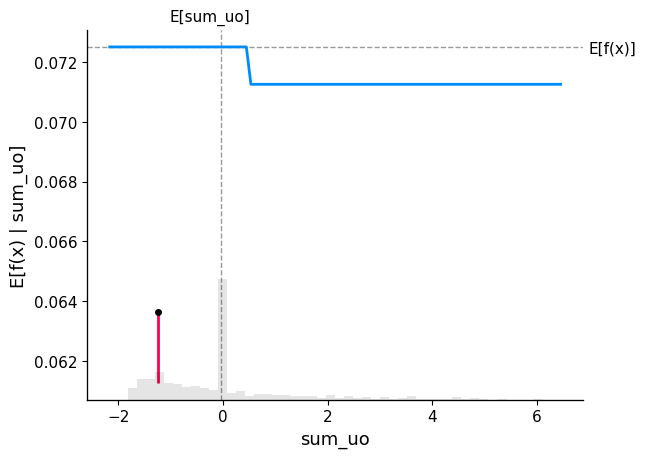

.values =
array([0.00237772])

.base_values =
array([0.06126656])

.data =
array([-1.24219104])
-----------------


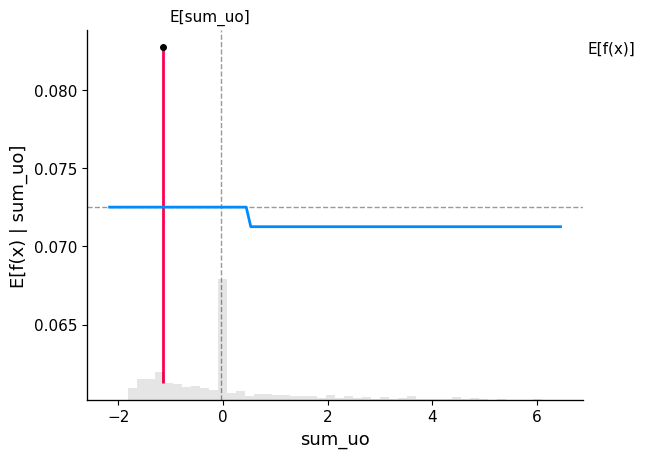

.values =
array([0.02147322])

.base_values =
array([0.06126656])

.data =
array([-1.14902994])
-----------------


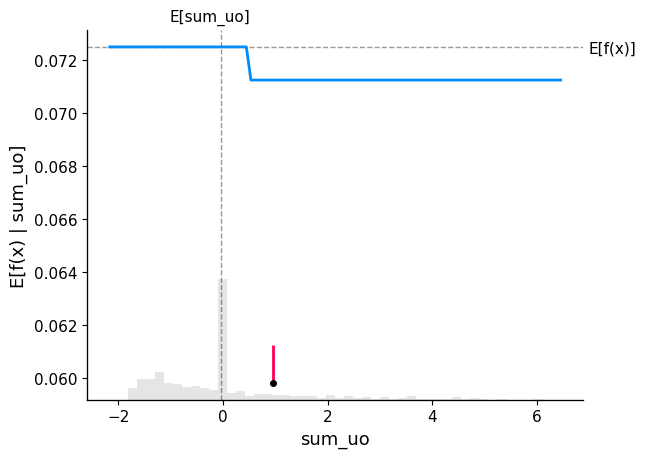

.values =
array([-0.00144448])

.base_values =
array([0.06126656])

.data =
array([0.9470948])
-----------------


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f99ee2b8b20>>
Traceback (most recent call last):
  File "/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


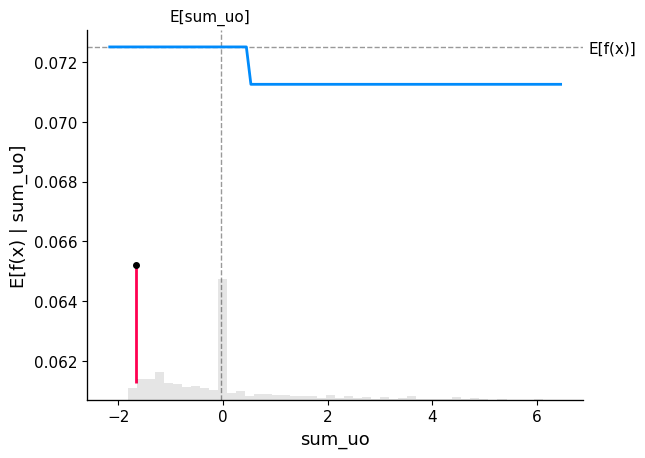

.values =
array([0.00394082])

.base_values =
array([0.06126656])

.data =
array([-1.66109979])
-----------------


In [ ]:
for sample_ind in range(5):
    print("-----------------")
    shap.partial_dependence_plot(
        "sum_uo",
        model.predict,
        X800,
        model_expected_value=True,
        feature_expected_value=True,
        ice=False,
        shap_values=shap_values[sample_ind : sample_ind + 1, :],
    )
    print(shap_values[sample_ind : sample_ind + 1, 'sum_uo'])

# Plots

## Beeswarm

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation.pkl
SHAP explanation loaded successfully.

Generating beeswarm plot for top 20 features...


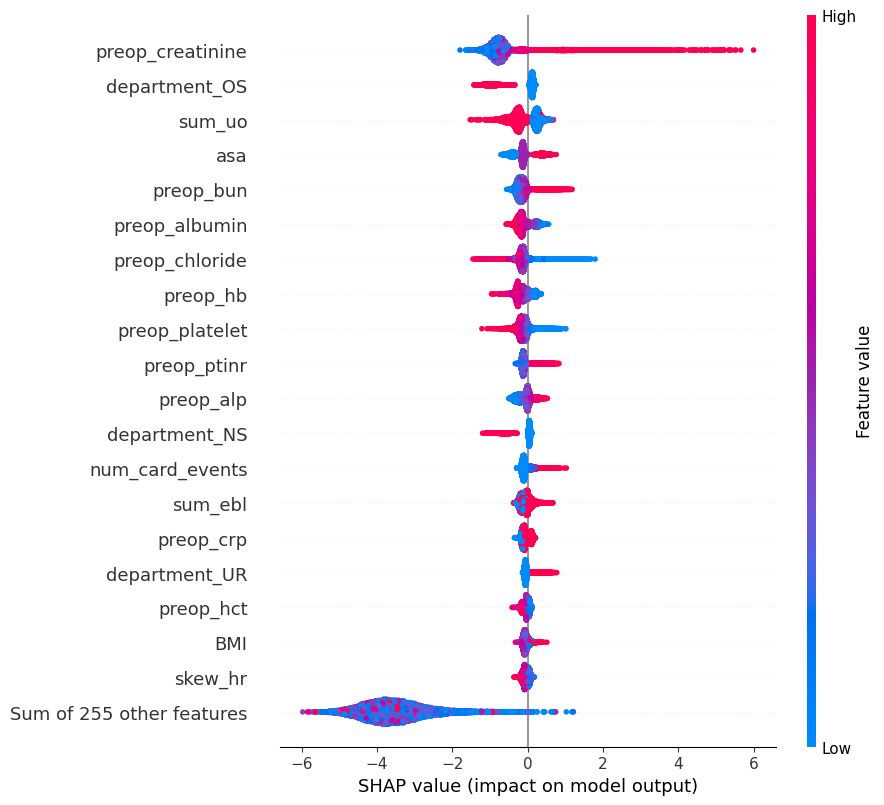

In [1]:
# =============================================================================
# Cell: Generate and Display SHAP Beeswarm Summary Plot
# =============================================================================
import os
import pickle
import shap
import matplotlib.pyplot as plt

# --- Configuration ---
# PLEASE VERIFY this path matches the results directory from your previous cells.
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# Number of top features you want to display on the plot
MAX_DISPLAY_FEATURES = 20

# --- File Paths ---
# Input: Path to the pickled SHAP explanation object
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')

# --- 1. Ensure SHAP JavaScript is initialized for interactive plots ---
# This is usually done once at the beginning of the notebook.
# Running it again is harmless.
shap.initjs()

# --- 2. Load the Pre-calculated SHAP Explanation Object ---
print(f"Loading SHAP explanation object from: {SHAP_VALUES_PATH}")

if not os.path.exists(SHAP_VALUES_PATH):
    print("\nERROR: SHAP file not found.")
    print("Please ensure you have run the main analysis notebook cell first,")
    print(f"and that the RESULTS_DIR path is set correctly.")
else:
    try:
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP explanation loaded successfully.")

        # --- 3. Generate and Display the Beeswarm Plot ---
        print(f"\nGenerating beeswarm plot for top {MAX_DISPLAY_FEATURES} features...")

        # Create a matplotlib figure to control size
        plt.figure(figsize=(12, 8))
        
        # The `show=True` default for this function will call `plt.show()`
        # which displays the plot directly in the notebook output.
        shap.plots.beeswarm(
            shap_explanation,
            max_display=MAX_DISPLAY_FEATURES
        )

    except Exception as e:
        print(f"\nAn error occurred: {e}")

# --- (Optional) 4. Save a High-Quality Copy of the Plot ---
# If you also want to save a PNG file for a presentation or paper,
# you can uncomment and run the following code in a new cell *after*
# the plot has been generated above.

# PLOT_OUTPUT_PATH = os.path.join(RESULTS_DIR, 'shap_beeswarm_summary_plot.png')
# fig = plt.gcf() # Get current figure
# fig.savefig(PLOT_OUTPUT_PATH, dpi=300, bbox_inches='tight')
# print(f"\nPlot saved to: {PLOT_OUTPUT_PATH}")
# plt.close(fig) # Close the figure to free up memory



## Positive Waterfall

Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Test set labels loaded.

Identifying Negative Cases in the Test Set...

Found 1 Negative cases to plot.
Generating a waterfall plot for each...
--------------------------------------------------
Displaying plot for Negative Case #1 (Test Set Index: 0)


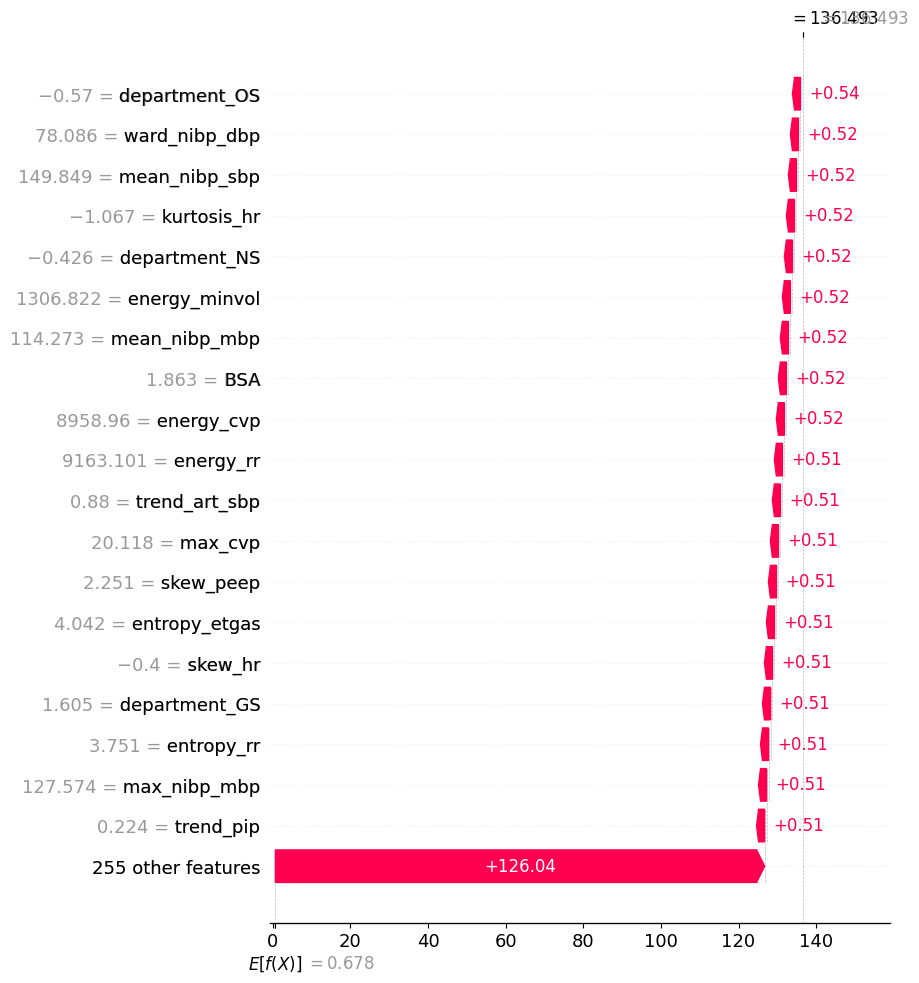

In [ ]:
# =============================================================================
# Cell: Generate Waterfall Plots for Individual Positive Cases
#
# Description:
# This cell identifies samples in the test set that are positive for the
# target variable ('aki_boolean' = 1) and generates a SHAP waterfall plot
# for each one. A waterfall plot provides a detailed, step-by-step
# explanation of how each feature contributed to the final prediction for a
# single observation.
# =============================================================================
import os
import pickle
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.special import expit

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# How many positive cases do you want to plot?
NUM_PLOTS_TO_GENERATE = 1

# Set to True if you want to find positive cases (aki_boolean = 1)
# Set to False if you want to find negative cases (aki_boolean = 0)
POSITIVE = False

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')
SHAP_VALUES_PROB_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_prob.pkl')

# --- 1. Load SHAP Explanation Object ---
# We load the probability output denormalized explanation object so that our values are clinically meaningful
#NOTE: change this to SHAP_VALUES_DENORM_PATH if you want go back to the previous plots
print(f"Loading SHAP explanation object from: {SHAP_VALUES_PROB_PATH}")
if not os.path.exists(SHAP_VALUES_PROB_PATH):
    print(f"\nERROR: SHAP file not found at {SHAP_VALUES_PROB_PATH}")
else:
    with open(SHAP_VALUES_PROB_PATH, 'rb') as f:
        shap_explanation = pickle.load(f)
    print("SHAP explanation loaded successfully.")

    # --- 2. Reload Original Data to get the y_test labels ---
    # We need the true outcomes (y_test) to identify the positive cases.
    # To ensure we get the *exact same* test set, we must repeat the
    # train/test split using the same data and the same RANDOM_STATE.
    print(f"\nReloading data from {DATA_PATH} to get test set labels...")
    df = pd.read_csv(DATA_PATH)
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    # Perform the exact same stratified split as in the original notebook
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )
    y_test = test_df[TARGET]
    # Reset index to align with the SHAP explanation object (which is 0-indexed)
    y_test = y_test.reset_index(drop=True)
    print("Test set labels loaded.")

    # --- 3. Find Positive/Negative Cases and Generate Plots ---
    # Decide if we're finding positive or negative cases
    if POSITIVE:
        y_val = 1
        case_type = "Positive"
    else:
        y_val = 0
        case_type = "Negative"
    print(f"\nIdentifying {case_type} Cases in the Test Set...")

    # Find the indices of the first N positive cases in the test set
    case_indices = y_test[y_test == y_val].head(NUM_PLOTS_TO_GENERATE).index

    print(f"\nFound {len(case_indices)} {case_type} cases to plot.")
    print("Generating a waterfall plot for each...")

    if len(case_indices) == 0:
        print(f"\nNo {case_type} cases found in the first part of the test set.")
    else:
        # Loop through the identified positive cases
        for i, idx in enumerate(case_indices):
            print("-" * 50)
            print(f"Displaying plot for {case_type} Case #{i+1} (Test Set Index: {idx})")
            # A waterfall plot is the modern, standard way to show a single explanation
            shap.plots.waterfall(shap_explanation[idx], max_display=20)



## Scatter Plot

In [4]:
# =============================================================================
# Cell 1: Notebook Setup and Configuration
#
# Description:
# This cell imports all necessary libraries and defines the configuration
# variables for the analysis. Edit the variables in the 'Configuration'
# section to match your environment and analysis needs.
# =============================================================================
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
import re

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = os.path.join(BASE_DATA_DIR, 'results/xgboost_analysis/')
OUTPUT_DIR = 'figures/scatters' # Directory to save plots

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')

# --- Model & Plotting Parameters ---
PLOTTING_ENABLED = True # <<< SET TO False TO DISABLE PLOT GENERATION
TARGET = 'aki_boolean'
RANDOM_STATE = 42
DPI = 400 # DPI for saved figures

# Set MAX_PLOTS to a number to limit the output (e.g., 10).
# Set to None to plot all features.
MAX_PLOTS = None


# =============================================================================
# Cell 2: Helper Function for Plotting
#
# Description:
# This cell contains the function responsible for generating a single
# SHAP interaction plot for a given feature. The plot is saved to a file
# with styling suitable for publications.
# =============================================================================
def plot_and_save_shap_interaction(shap_explanation, feature_name, y_true, output_dir):
    """
    Generates and saves a publication-ready SHAP interaction plot.

    This plot shows the feature's value vs. its SHAP value. Points are colored
    by the true outcome (e.g., AKI Positive/Negative). A trendline is fitted
    to show the general relationship.

    Args:
        shap_explanation (shap.Explanation): The SHAP explanation object.
        feature_name (str): The name of the feature to plot.
        y_true (pd.Series or np.ndarray): A boolean array of true outcomes.
        output_dir (str): The directory where the plot image will be saved.
    """
    # Sanitize feature name for use in the filename
    safe_feature_name = re.sub(r'[^a-zA-Z0-9_-]', '_', feature_name)
    print(f"--- Plotting interaction for: {feature_name} ---")
    
    # Use a publication-ready style context
    with plt.style.context('seaborn-v0_8-paper'):
        fig, ax = plt.subplots(figsize=(8, 6))

        try:
            # --- 1. Extract Data for Plotting ---
            feature_index = list(shap_explanation.feature_names).index(feature_name)
            shap_vals = shap_explanation.values[:, feature_index]
            feature_vals = shap_explanation.data[:, feature_index]

            # --- 2. Create the Scatter Plot ---
            ax.scatter(feature_vals[~y_true], shap_vals[~y_true], s=15, zorder=3, 
                       color='royalblue', alpha=0.6, label='AKI Negative')
            ax.scatter(feature_vals[y_true], shap_vals[y_true], s=15, zorder=3, 
                       color='crimson', alpha=0.6, label='AKI Positive')

            # --- 3. Calculate and Plot Trendline ---
            valid_indices = ~np.isnan(feature_vals) & ~np.isnan(shap_vals)
            if np.any(valid_indices):
                slope, intercept, _, _, _ = linregress(feature_vals[valid_indices], shap_vals[valid_indices])
                min_x, max_x = np.nanmin(feature_vals), np.nanmax(feature_vals)
                trend_x = np.linspace(min_x, max_x, 100)
                trendline = slope * trend_x + intercept

                if abs(slope) > 1e-4:
                    x_intercept = -intercept / slope
                    label = f'Trendline (Slope: {slope:.2g}, X-Intercept: {x_intercept:.2f})'
                else:
                    label = f'Trendline (Slope: {slope:.2g})'
                
                ax.plot(trend_x, trendline, color='black', label=label, lw=2.5, zorder=5)

            # --- 4. Finalize and Save Plot (Publication Styling) ---
            font_settings = {'fontsize': 14, 'fontweight': 'bold'}
            ax.set_xlabel(f"Feature Value: {feature_name}", **font_settings)
            ax.set_ylabel(f"SHAP Value for {feature_name}", **font_settings)
            ax.set_title(f"SHAP Interaction Plot for {feature_name}", fontsize=16, fontweight='bold', pad=20)

            ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

            ax.grid(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            ax.legend(fontsize=12, loc='best')
            plt.tight_layout()

            # For vector graphics (ideal for publications), change file extension to .svg or .pdf
            filename = f"{safe_feature_name}_interaction_plot.png"
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, dpi=DPI, bbox_inches='tight')

        except Exception as e:
            print(f"An unexpected error occurred while plotting '{feature_name}': {e}")
        finally:
            plt.close(fig)


# =============================================================================
# Cell 3: Load Data and SHAP Object
#
# Description:
# This cell loads the pre-computed SHAP explanation object. It then reloads
# the original dataset and performs the *exact same* train-test split to
# retrieve the outcome labels (y_test) corresponding to the SHAP values.
# =============================================================================
print(f"Loading SHAP explanation object from: {SHAP_VALUES_DENORM_PATH}")
if not os.path.exists(SHAP_VALUES_DENORM_PATH):
    raise FileNotFoundError(f"SHAP file not found at {SHAP_VALUES_DENORM_PATH}. Please ensure the file exists.")

with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
    shap_explanation = pickle.load(f)
print("SHAP explanation loaded successfully.")

# Reload original data to get the y_test labels needed for coloring the plots
print(f"\nReloading data from {DATA_PATH} to get test set labels...")
df = pd.read_csv(DATA_PATH)
if 'op_id' in df.columns:
    df = df.drop(columns=['op_id'])

# Perform the exact same stratified split as in the original analysis
print("Performing train-test split to align with SHAP values...")
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df[TARGET],
    random_state=RANDOM_STATE
)
y_test = test_df[TARGET].astype(bool)
print("Test set labels (y_test) successfully isolated.")


# =============================================================================
# Cell 4: Generate and Save All Plots
#
# Description:
# This cell checks if plotting is enabled. If so, it creates the output
# directory and iterates through the features to create and save the plots.
# =============================================================================
if PLOTTING_ENABLED:
    # Create the output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"\nPlots will be saved to: '{os.path.abspath(OUTPUT_DIR)}'")

    all_feature_names = shap_explanation.feature_names
    
    if MAX_PLOTS is not None and MAX_PLOTS < len(all_feature_names):
        features_to_plot = all_feature_names[:MAX_PLOTS]
        print(f"\nGenerating plots for the first {MAX_PLOTS} features.")
    else:
        features_to_plot = all_feature_names
        print(f"\nGenerating plots for all {len(all_feature_names)} features.")
    
    # Loop through the features and generate a plot for each one
    for feature_name in features_to_plot:
        plot_and_save_shap_interaction(
            shap_explanation,
            feature_name,
            y_test.values,
            OUTPUT_DIR
        )

    print(f"\n\n--- Plot generation complete. {len(features_to_plot)} plots saved. ---")
else:
    print("\n\n--- Plotting is disabled by the PLOTTING_ENABLED flag. Skipping plot generation. ---")

print("\n--- Notebook execution finished. ---")


Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Performing train-test split to align with SHAP values...
Test set labels (y_test) successfully isolated.

Plots will be saved to: '/home/server/Projects/VitalDB-Dimensionality-Reduction/create_results/figures/scatters'

Generating plots for all 274 features.
--- Plotting interaction for: age ---
--- Plotting interaction for: sex ---
--- Plotting interaction for: height ---
--- Plotting interaction for: weight ---
--- Plotting interaction for: asa ---
--- Plotting interaction for: emop ---
--- Plotting interaction for: BSA ---
--- Plotting interaction for: BMI ---
--- Plotting interaction for: booking_case_length ---
--- Plotting interaction for: num_card_events ---
--- Plotting interaction for: op_len ---
--- Plotting interaction f

## Partial Dependence Plot 

In [5]:
# =============================================================================
# Cell 1: Notebook Setup and Configuration
#
# Description:
# This cell imports all necessary libraries and defines the configuration
# variables for the analysis. Edit the variables in the 'Configuration'
# section to match your environment and analysis needs.
# =============================================================================
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from itertools import combinations
import re

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = os.path.join(BASE_DATA_DIR, 'results/xgboost_analysis/')
OUTPUT_DIR = 'figures/cross_scatters' # Directory to save plots

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')

# --- Model & Plotting Parameters ---
PLOTTING_ENABLED = True # <<< SET TO False TO DISABLE PLOT GENERATION
TARGET = 'aki_boolean'
RANDOM_STATE = 42
DPI = 400 # DPI for saved figures

# Set MAX_FEATURES_FOR_INTERACTION to limit the number of features to pair up.
# For example, 10 features will produce (10*9)/2 = 45 plots.
# Set to None to plot interactions for all features.
MAX_FEATURES_FOR_INTERACTION = None


# =============================================================================
# Cell 2: Helper Function for Plotting
#
# Description:
# This cell contains the function responsible for generating a single
# SHAP dependence plot for a given pair of features, showing their interaction.
# The plot is saved to a file instead of being displayed.
# =============================================================================
def plot_and_save_shap_dependence(shap_explanation, main_feature, interaction_feature, output_dir):
    """
    Generates and saves a SHAP dependence plot for a pair of features.

    This plot shows the main feature's value vs. its SHAP value. Points are colored
    by the value of the interaction feature to show interaction effects.

    Args:
        shap_explanation (shap.Explanation):
            The SHAP explanation object.
        main_feature (str):
            The name of the feature for the X-axis and SHAP values.
        interaction_feature (str):
            The name of the feature to color the points by.
        output_dir (str):
            The directory where the plot image will be saved.
    """
    # Sanitize feature names for use in filenames
    safe_main_feature = re.sub(r'[^a-zA-Z0-9_-]', '_', main_feature)
    safe_interaction_feature = re.sub(r'[^a-zA-Z0-9_-]', '_', interaction_feature)
    
    print(f"--- Plotting: {main_feature} (SHAP) vs. {interaction_feature} (Color) ---")
    
    fig, ax = plt.subplots(figsize=(10, 6))

    try:
        # --- 1. Extract Data for Plotting ---
        feature_names = list(shap_explanation.feature_names)
        main_feature_index = feature_names.index(main_feature)
        interaction_feature_index = feature_names.index(interaction_feature)

        main_feature_vals = shap_explanation.data[:, main_feature_index]
        shap_vals = shap_explanation.values[:, main_feature_index]
        interaction_vals = shap_explanation.data[:, interaction_feature_index]

        # --- 2. Create the Scatter Plot ---
        # Use a color map to show the interaction feature's effect
        scatter = ax.scatter(main_feature_vals, shap_vals, s=10, zorder=3,
                             c=interaction_vals, cmap='viridis', alpha=0.7)
        
        # Add a colorbar to explain the coloring
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(f'Interaction Feature: {interaction_feature}', fontsize=12)

        # --- 3. Finalize and Save Plot ---
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel(f"Feature Value: {main_feature}", fontsize=12)
        ax.set_ylabel(f"SHAP Value for {main_feature}", fontsize=12)
        ax.set_title(f"SHAP Dependence Plot: {main_feature} vs. {interaction_feature}", fontsize=14)

        # Construct file path and save the figure
        filename = f"{safe_main_feature}_vs_{safe_interaction_feature}_interaction.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=DPI, bbox_inches='tight')

    except Exception as e:
        print(f"An unexpected error occurred while plotting '{main_feature}' vs '{interaction_feature}': {e}")
    finally:
        plt.close(fig) # Close the figure to free memory


# =============================================================================
# Cell 3: Load Data and SHAP Object
#
# Description:
# This cell loads the pre-computed SHAP explanation object. It's kept separate
# for clarity. The logic to reload original data is kept in case it's needed
# for other validation steps, but is not used for the dependence plots.
# =============================================================================
print(f"Loading SHAP explanation object from: {SHAP_VALUES_DENORM_PATH}")
if not os.path.exists(SHAP_VALUES_DENORM_PATH):
    raise FileNotFoundError(f"SHAP file not found at {SHAP_VALUES_DENORM_PATH}. Please ensure the file exists.")

with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
    shap_explanation = pickle.load(f)
print("SHAP explanation loaded successfully.")

# The y_test object is not needed for dependence plots but is kept for context
print(f"\nReloading data from {DATA_PATH} to get test set labels...")
df = pd.read_csv(DATA_PATH)
if 'op_id' in df.columns:
    df = df.drop(columns=['op_id'])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=RANDOM_STATE)
y_test = test_df[TARGET].astype(bool)
print("Test set labels (y_test) loaded.")


# =============================================================================
# Cell 4: Generate and Save All Plots
#
# Description:
# This cell checks if plotting is enabled. If so, it creates the output
# directory, generates all unique pairs of features, and then iterates
# through them to create and save the SHAP dependence plots.
# =============================================================================
if PLOTTING_ENABLED:
    # Create the output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"\nPlots will be saved to: '{os.path.abspath(OUTPUT_DIR)}'")

    all_feature_names = shap_explanation.feature_names

    if MAX_FEATURES_FOR_INTERACTION is not None and MAX_FEATURES_FOR_INTERACTION < len(all_feature_names):
        features_to_plot = all_feature_names[:MAX_FEATURES_FOR_INTERACTION]
        print(f"\nGenerating interaction plots for the first {MAX_FEATURES_FOR_INTERACTION} features.")
    else:
        features_to_plot = all_feature_names
        print(f"\nGenerating interaction plots for all {len(all_feature_names)} features.")

    # Generate unique pairs of features using itertools.combinations
    feature_pairs = list(combinations(features_to_plot, 2))
    print(f"Found {len(feature_pairs)} unique feature pairs to plot.")

    # Loop through the unique pairs and generate a plot for each
    for main_feature, interaction_feature in feature_pairs:
        plot_and_save_shap_dependence(
            shap_explanation,
            main_feature,
            interaction_feature,
            OUTPUT_DIR
        )
        # We also plot the reverse interaction
        plot_and_save_shap_dependence(
            shap_explanation,
            interaction_feature,
            main_feature,
            OUTPUT_DIR
        )

    print(f"\n\n--- Plot generation complete. {len(feature_pairs) * 2} plots saved. ---")
else:
    print("\n\n--- Plotting is disabled by the PLOTTING_ENABLED flag. Skipping plot generation. ---")

print("\n--- Notebook execution finished. ---")


Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Test set labels (y_test) loaded.

Plots will be saved to: '/home/server/Projects/VitalDB-Dimensionality-Reduction/create_results/figures/cross_scatters'

Generating interaction plots for all 274 features.
Found 37401 unique feature pairs to plot.
--- Plotting: age (SHAP) vs. sex (Color) ---
--- Plotting: sex (SHAP) vs. age (Color) ---
--- Plotting: age (SHAP) vs. height (Color) ---
--- Plotting: height (SHAP) vs. age (Color) ---
--- Plotting: age (SHAP) vs. weight (Color) ---
--- Plotting: weight (SHAP) vs. age (Color) ---


KeyboardInterrupt: 